# Equações Homogêneas de Ordem Superior

Considere a equação homogênea de ordem $n$ com coeficientes constantes

$$
a_n y^{(n)} + a_{n-1}y^{(n-1)} + \cdots + a_1 y' + a_0 y = 0, \qquad a_n\neq0.
$$

A ideia é exatamente a mesma da segunda ordem: testar $y=e^{rt}$. Como $\dfrac{d^k}{dt^k}e^{rt}=r^ke^{rt}$, a substituição dá

$$
e^{rt}\big(a_nr^n + a_{n-1}r^{n-1}+\cdots+a_1r+a_0\big) = 0
\quad\Longrightarrow\quad
Z(r) = a_nr^n + a_{n-1}r^{n-1}+\cdots+a_1r+a_0 = 0.
$$

$Z(r)$ é o **polinômio característico**. Pelo Teorema Fundamental da Álgebra, ele tem exatamente $n$ raízes (complexas, contando multiplicidades). Cada raiz vai contribuir com soluções, e no total teremos as $n$ soluções de que precisamos.

## O resultado geral

**Teorema.** Considere a equação $a_n y^{(n)} + \cdots + a_1 y' + a_0 y = 0$, com $a_0,\dots,a_n$ constantes reais e $a_n\neq0$.

1. **(Existência e unicidade)** Dadas $n$ condições iniciais $y(t_0)=y_0,\ y'(t_0)=y_1,\ \dots,\ y^{(n-1)}(t_0)=y_{n-1}$, o PVI tem uma única solução, definida para todo $t$.

2. **(Solução geral)** Se $y_1,\dots,y_n$ são soluções cujo Wronskiano
$$
W(y_1,\dots,y_n) = \begin{vmatrix} y_1 & y_2 & \cdots & y_n\\ y_1' & y_2' & \cdots & y_n'\\ \vdots & \vdots & & \vdots\\ y_1^{(n-1)} & y_2^{(n-1)} & \cdots & y_n^{(n-1)}\end{vmatrix}
$$
não se anula, então toda solução é da forma $y=c_1y_1+c_2y_2+\cdots+c_ny_n$.

3. **(Conjunto fundamental)** Um tal conjunto de $n$ soluções é obtido a partir das raízes de $Z(r)$, conforme a tabela:

| Raiz de $Z(r)$ | Multiplicidade | Soluções correspondentes |
|---|---|---|
| $r$ real | $s$ | $e^{rt},\ te^{rt},\ \dots,\ t^{s-1}e^{rt}$ |
| $\lambda\pm i\mu$ (par complexo) | $s$ | $e^{\lambda t}\cos\mu t,\ e^{\lambda t}\,\text{sen}\,\mu t,\ \dots,\ t^{s-1}e^{\lambda t}\cos\mu t,\ t^{s-1}e^{\lambda t}\,\text{sen}\,\mu t$ |

É exatamente a mesma receita da segunda ordem — real distinta, repetida, complexa — com uma única novidade: uma raiz pode aparecer **três ou mais vezes**, e então seguimos multiplicando por $t$: $e^{rt}, te^{rt}, t^2e^{rt},\dots$ Como para a segunda ordem, o Wronskiano dessas funções nunca se anula, então a tabela sempre fornece a solução geral.

O item 2 também explica por que um PVI de ordem $n$ precisa de $n$ condições: para achar $c_1,\dots,c_n$ resolvemos um sistema linear $n\times n$, cuja matriz é exatamente a do Wronskiano.

### A parte difícil: achar as raízes

Na prática, a dificuldade passa a ser **fatorar** $Z(r)$, que agora tem grau $3$, $4$ ou mais. Duas dicas:

* **Raízes racionais.** Se $Z(r)$ tem coeficientes inteiros e $r=p/q$ é uma raiz racional (fração irredutível), então $p$ divide $a_0$ e $q$ divide $a_n$. Isso dá uma lista finita de candidatos para testar. Achada uma raiz $r_1$, dividimos $Z(r)$ por $(r-r_1)$ (Briot–Ruffini) e o grau cai.
* **Produtos notáveis.** Muitas vezes $Z(r)$ é uma diferença de quadrados ou um quadrado perfeito em $r^2$, como em $r^4-1$ ou $r^4+8r^2+16$.

E, claro, o computador ajuda: `numpy.roots` encontra as raízes numericamente.

### Exemplo 1: raízes reais distintas

Resolva

$$
y''' - 6y'' + 11y' - 6y = 0, \qquad y(0)=1,\ y'(0)=0,\ y''(0)=0.
$$

A equação característica é $r^3-6r^2+11r-6=0$. Os candidatos a raiz racional são os divisores de $6$: $\pm1,\pm2,\pm3,\pm6$. Testando, $r=1$ funciona ($1-6+11-6=0$). Dividindo por $(r-1)$:

$$
r^3-6r^2+11r-6 = (r-1)(r^2-5r+6) = (r-1)(r-2)(r-3).
$$

Três raízes reais distintas, $r=1,2,3$, então

$$
y = c_1e^{t} + c_2e^{2t} + c_3e^{3t}.
$$

Para as condições iniciais, derivamos duas vezes e fazemos $t=0$:

$$
\begin{cases}
c_1 + c_2 + c_3 = 1\\
c_1 + 2c_2 + 3c_3 = 0\\
c_1 + 4c_2 + 9c_3 = 0
\end{cases}
\quad\Longrightarrow\quad c_1=3,\ c_2=-3,\ c_3=1.
$$

Logo, $y(t) = 3e^{t}-3e^{2t}+e^{3t}$. Quando $t\to\infty$, o termo dominante é o da maior raiz, $e^{3t}$, com coeficiente positivo: $y\to+\infty$.

Para equações de ordem alta, vale a pena deixar o computador achar as raízes e resolver o sistema:

Raízes de r^3 - 6r^2 + 11r - 6: [3. 2. 1.]
Constantes: {c1: 3, c2: -3, c3: 1}


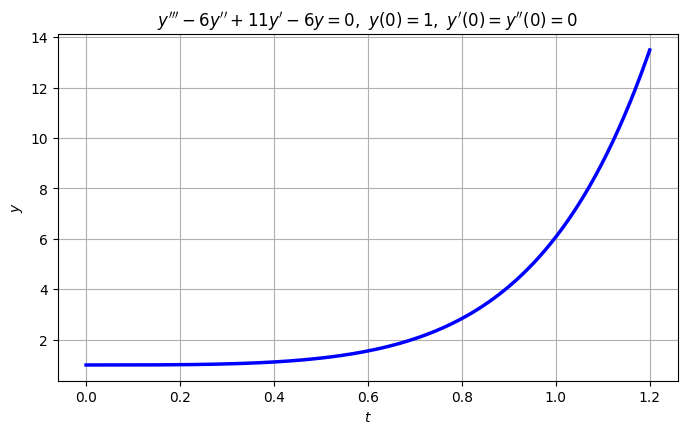

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

print("Raízes de r^3 - 6r^2 + 11r - 6:", np.roots([1, -6, 11, -6]))

t = sp.symbols('t')
c1, c2, c3 = sp.symbols('c1 c2 c3')
y = c1*sp.exp(t) + c2*sp.exp(2*t) + c3*sp.exp(3*t)
constantes = sp.solve([y.subs(t, 0) - 1,
                       sp.diff(y, t).subs(t, 0),
                       sp.diff(y, t, 2).subs(t, 0)], [c1, c2, c3])
print("Constantes:", constantes)

t_vals = np.linspace(0, 1.2, 200)
y_vals = 3*np.exp(t_vals) - 3*np.exp(2*t_vals) + np.exp(3*t_vals)

plt.figure(figsize=(8, 4.5))
plt.plot(t_vals, y_vals, 'b', linewidth=2.5)
plt.title(r"$y'''-6y''+11y'-6y=0,\ y(0)=1,\ y'(0)=y''(0)=0$")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.grid(True)
plt.show()

### Exemplo 2: raízes reais e complexas juntas

Resolva

$$
y^{(4)} - y = 0, \qquad y(0)=\tfrac72,\ y'(0)=-4,\ y''(0)=\tfrac52,\ y'''(0)=-2.
$$

A equação característica é uma diferença de quadrados:

$$
r^4-1 = (r^2-1)(r^2+1) = 0 \quad\Longrightarrow\quad r=\pm1,\ \ r=\pm i.
$$

As raízes reais dão $e^{t}$ e $e^{-t}$; o par complexo $\pm i$ (com $\lambda=0$, $\mu=1$) dá $\cos t$ e $\text{sen}\,t$:

$$
y = c_1e^{t} + c_2e^{-t} + c_3\cos t + c_4\,\text{sen}\,t.
$$

Impondo as quatro condições iniciais (um sistema $4\times4$), obtém-se $c_1=0$, $c_2=3$, $c_3=\tfrac12$, $c_4=-1$:

$$
y(t) = 3e^{-t} + \tfrac12\cos t - \text{sen}\,t.
$$

Repare num detalhe curioso: as condições iniciais fizeram o coeficiente de $e^{t}$ (o termo que cresce) ser **exatamente zero**, e a solução se acomoda numa oscilação limitada. O que acontece se mexermos só um pouquinho nas condições iniciais? Trocando $y'''(0)=-2$ por $y'''(0)=-\tfrac{15}{8}$, a solução vira

$$
y(t) = \tfrac{1}{32}e^{t} + \tfrac{95}{32}e^{-t} + \tfrac12\cos t - \tfrac{17}{16}\,\text{sen}\,t.
$$

Os coeficientes quase não mudaram — mas agora o termo $\tfrac1{32}e^{t}$ está presente, e ele domina completamente a solução depois de pouco tempo:

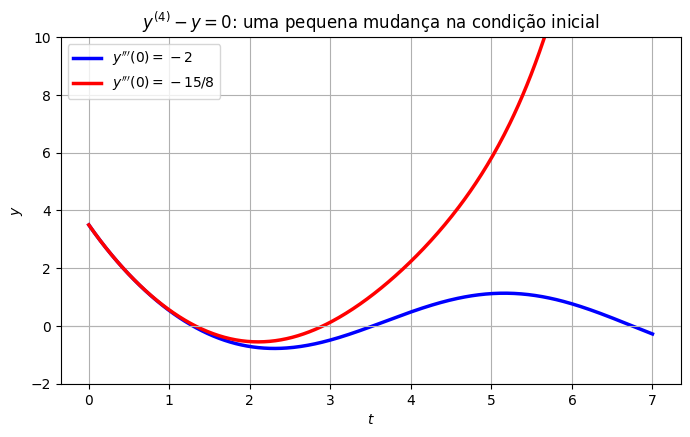

In [2]:
t_vals = np.linspace(0, 7, 400)
y_a = 3*np.exp(-t_vals) + 0.5*np.cos(t_vals) - np.sin(t_vals)
y_b = np.exp(t_vals)/32 + 95*np.exp(-t_vals)/32 + 0.5*np.cos(t_vals) - 17*np.sin(t_vals)/16

plt.figure(figsize=(8, 4.5))
plt.plot(t_vals, y_a, 'b', linewidth=2.5, label=r"$y'''(0)=-2$")
plt.plot(t_vals, y_b, 'r', linewidth=2.5, label=r"$y'''(0)=-15/8$")
plt.axhline(0, color='0.7', linewidth=0.8)
plt.ylim(-2, 10)
plt.title(r"$y^{(4)}-y=0$: uma pequena mudança na condição inicial")
plt.xlabel("$t$"); plt.ylabel("$y$")
plt.legend()
plt.grid(True)
plt.show()

### Exemplo 3: raízes repetidas

**(a) Uma raiz real tripla.** Encontre a solução geral de $y''' - 3y'' + 3y' - y = 0$.

A equação característica é um cubo perfeito: $r^3-3r^2+3r-1=(r-1)^3=0$. A raiz $r=1$ aparece **três** vezes, então seguimos multiplicando por $t$ até ter três soluções:

$$
y = c_1e^{t} + c_2te^{t} + c_3t^2e^{t} = (c_1+c_2t+c_3t^2)\,e^{t}.
$$

**(b) Um par complexo duplo.** Encontre a solução geral de $y^{(4)} + 8y'' + 16y = 0$.

A equação característica é um quadrado perfeito em $r^2$: $r^4+8r^2+16=(r^2+4)^2=0$. O par $r=\pm2i$ aparece **duas** vezes. A primeira ocorrência dá $\cos2t$ e $\text{sen}\,2t$; a segunda, multiplicando por $t$, dá $t\cos2t$ e $t\,\text{sen}\,2t$:

$$
y = (c_1+c_2t)\cos2t + (c_3+c_4t)\,\text{sen}\,2t.
$$

Repare que pares complexos repetidos só podem aparecer a partir da ordem $4$.

## Comportamento quando $t\to\infty$

Como a solução geral é uma soma de termos do tipo $t^ke^{\lambda t}$ (vezes cossenos e senos, no caso complexo), quem decide o comportamento a longo prazo é a **maior parte real** entre as raízes de $Z(r)$ (desde que o coeficiente correspondente não seja nulo, como vimos no Exemplo 2):

* se todas as raízes têm parte real negativa, toda solução tende a zero;
* se alguma raiz tem parte real positiva, as soluções em geral crescem sem limite;
* raízes com parte real nula dão oscilações que não crescem nem decaem — a menos que sejam repetidas, quando o fator $t^k$ faz a amplitude crescer.

Voltando às duas massas da seção anterior: $r^4+7r^2+6=(r^2+1)(r^2+6)$ tem raízes $\pm i$ e $\pm i\sqrt6$, todas com parte real nula e simples. Pela tabela, $u_1(t)=c_1\cos t+c_2\,\text{sen}\,t+c_3\cos\sqrt6t+c_4\,\text{sen}\,\sqrt6t$: uma superposição de dois modos com frequências $1$ e $\sqrt6$ — exatamente o que a simulação mostrou.